#### 1- Entropia e Ganho de Informação

A entropia de um conjunto $( S )$ é definida como:

$
H(S) = - \sum_{i=1}^{n} p_i \log_2 p_i
$

onde $( p_i )$ é a proporção de cada classe no conjunto de dados.

${0.5cm}$
#### 2. Ganho de Informação (IG - Information Gain)

O ganho de informação mede a redução da incerteza ao dividir o conjunto de dados com base em um atributo. A fórmula é:

O ganho de informação ao dividir $( S )$ com base em um atributo $( A )$ é dado por:

$  IG(S, A) = H(S) - \sum_{v \in A} \frac{|S_v|}{|S|} H(S_v) $

$$ onde:$$

   $$  ( S_v ) são\ os\ subconjuntos\ criados\ pela\ divisão.$$

   
  $$ ( \frac{|S_v|}{|S|} )\ representa\ o\ peso\ do\ subconjunto\ em\ relação\ ao\ total.$$



𝑆 é o conjunto total de dados.

𝐴 é o atributo escolhido para a divisão.

𝑆𝑣 são os subconjuntos gerados ao dividir 𝑆 pelo atributo 𝐴.

|𝑆𝑣|/|𝑆∣ é o peso de cada subconjunto.

𝐻(𝑆𝑣) é a entropia de cada subconjunto.


Entropy

$( p_i )$ :  é a proporção de cada classe no conjunto de dados.

Conjunto de 10 exemplos, onde 6 são positivos e 4 são negativos. 

$
H(S) = (-)\ [(\frac{6}{10}) * \log_2 * (\frac{6}{10})  + (\frac{4}{10}) * \log_2 *(\frac{4}{10}) ]
$

$
H(S) = 0,97 
$


In [38]:
import numpy as np
from collections import Counter

H_s= -((6 / 10) * np.log2(6/10) + (4 / 10) * np.log2(4/10) )
H_s

0.9709505944546686

In [39]:
def entropy(y):
    """Calcula a entropia de um conjunto de rótulos y."""
    total = len(y)
    counts = Counter(y)
    return -sum((count / total) * np.log2(count / total) for count in counts.values())

def information_gain(y, X_column):
    """Calcula o ganho de informação ao dividir y com base em um atributo X_column."""
    H_before = entropy(y)
    
    # Encontrar os valores únicos do atributo
    values, counts = np.unique(X_column, return_counts=True)
    
    # Calcular a entropia ponderada após a divisão
    H_after = sum((counts[i] / len(y)) * entropy(y[X_column == value]) for i, value in enumerate(values))
    
    return H_before - H_after

# Exemplo de uso:
y = np.array(["Positivo", "Positivo", "Negativo", "Positivo", "Negativo", "Negativo", "Positivo"])
X_column = np.array(["Sol", "Sol", "Chuva", "Sol", "Chuva", "Chuva", "Sol"])  # Exemplo de atributo

print("Entropia inicial:", entropy(y))
print("Ganho de informação para o atributo X_column:", information_gain(y, X_column))

Entropia inicial: 0.9852281360342515
Ganho de informação para o atributo X_column: 0.9852281360342515


# 4.4) Base principal  - Árvore de decisão 

Exemplo básico de entropia

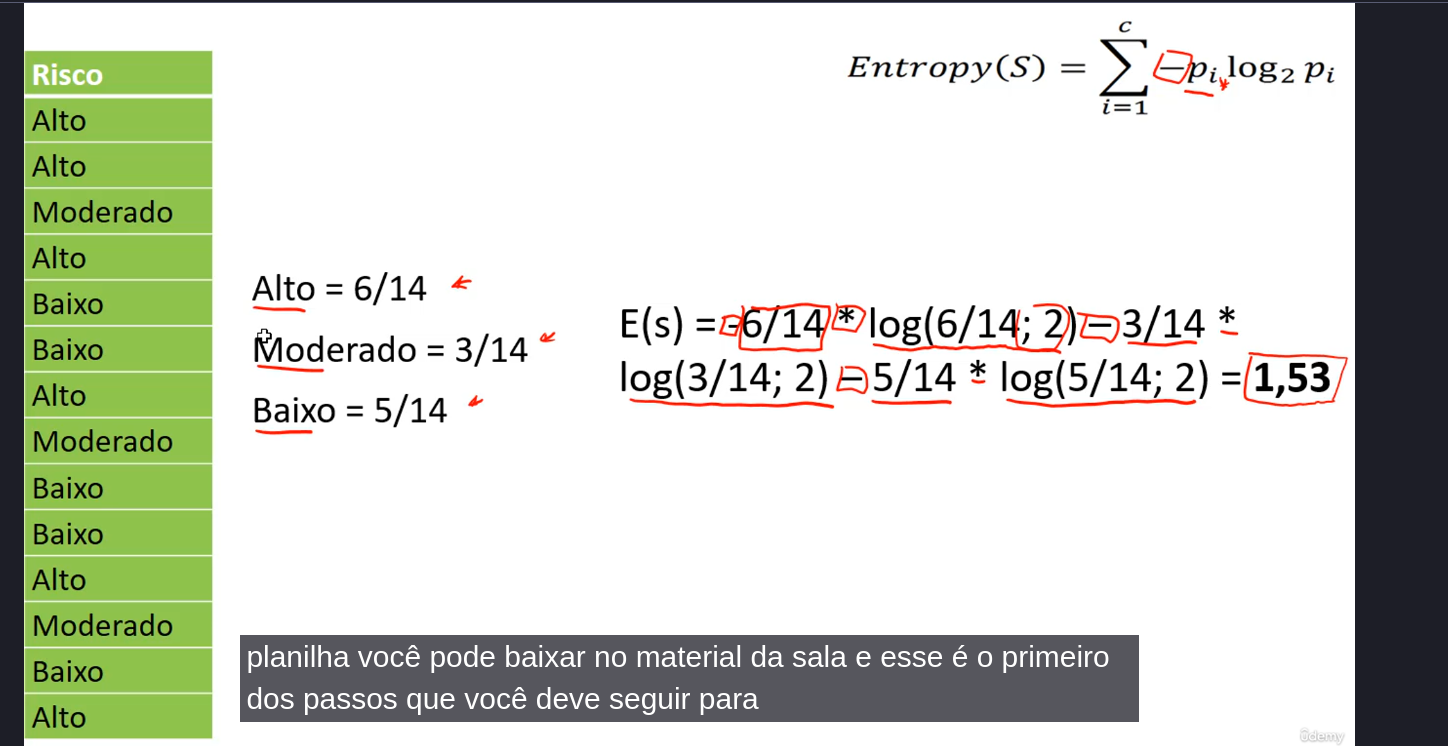


In [40]:
H_s= -((6 / 14) * np.log2(6/14) + (3 / 14) * np.log2(3/14) + (5 / 14) * np.log2(5/14) )
H_s

1.5306189948485174


- Ganho de informação 

Ganho de informação da histórica de crédito

Ganho de informação do atributo divida 

Ganho de informação do atributo garantias
 
Ganho de informação do atributo renda


o atributo que tiver o maior ganho, ou o maior valor ou informações; Considerado assim o atributo mais importante  vai estar na raiz da árvore. 

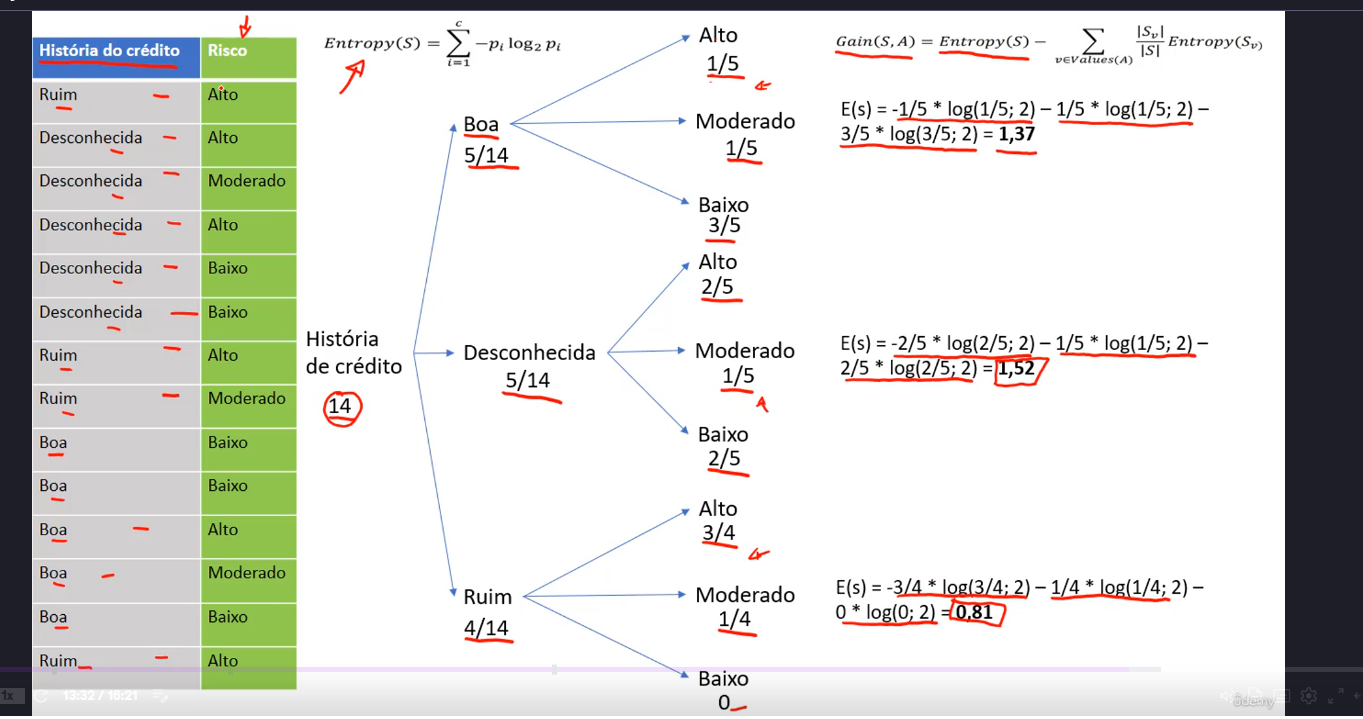

In [41]:
E_s_Cboa = -((1 / 5) * np.log2(1/5) + (1 / 5) * np.log2(1/5) + (3/ 5) * np.log2(3/5) )
print(E_s_Cboa)

E_s_Cdesconhecida = -((2 / 5) * np.log2(2/5) + (1 / 5) * np.log2(1/5) + (2/ 5) * np.log2(2/5) )
print(E_s_Cdesconhecida)

E_s_Cruim = -((3 / 4) * np.log2(3/4) + (1/4) * np.log2(1/4) + 0 )
print(E_s_Cruim)


1.3709505944546687
1.5219280948873621
0.8112781244591328


Entropy(S) → é o resultado do primeiro caso, da entropia baseado na coluna de risco.



In [42]:
H_s

1.5306189948485174


### Ganho Histórico =  Entropia do risco (H_s) - (atributo* E(s_boa) + atributo* E(s_desconhecida) + atributo* E(s_ruim)

                            

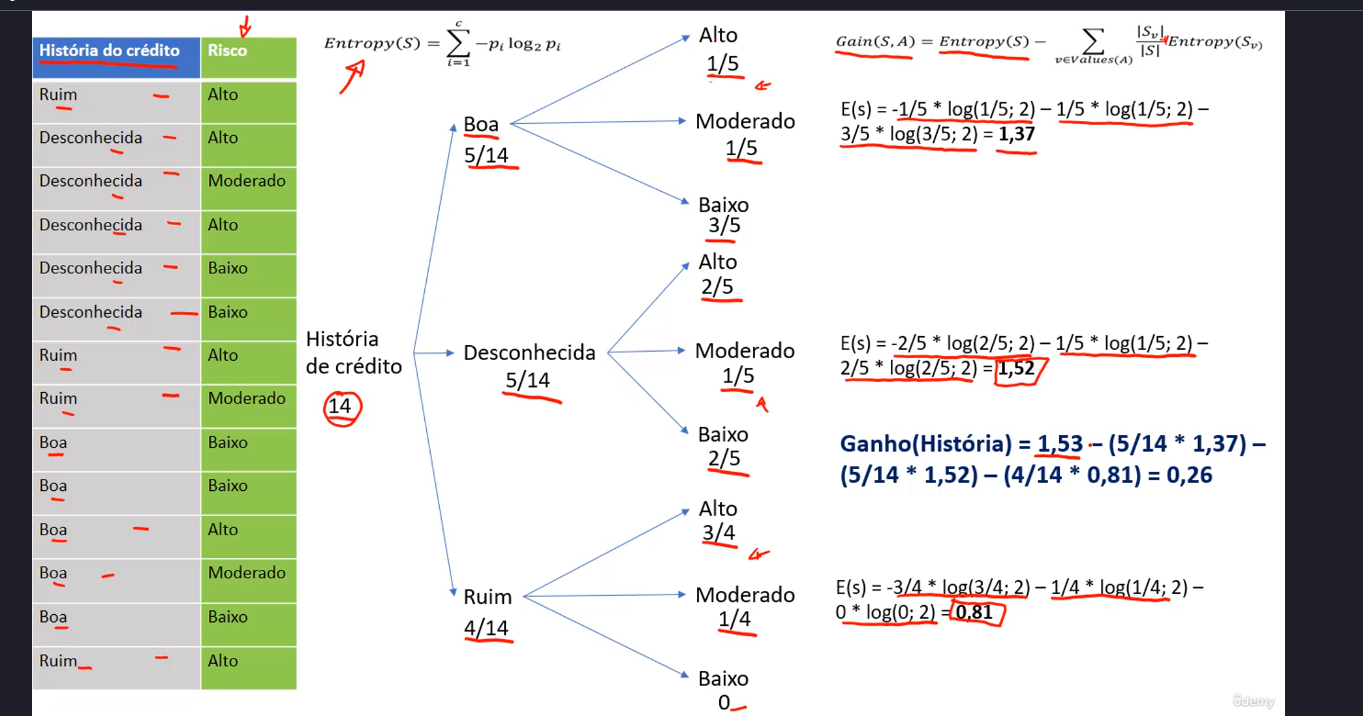

In [43]:
Ganho_historico_credito =  (H_s) - (5/14* E_s_Cboa + 5/14* E_s_Cdesconhecida + 4/14* E_s_Cruim)
Ganho_historico_credito

0.26565428452375417

#### 4.5) Para saber se o atributo é bom ou ruim, teremos que analisar os outros 3 atributos (garantia, dívida e renda). Aquele que tiver o maior valor vai ser colocado na raiz da árvore de decisão. 



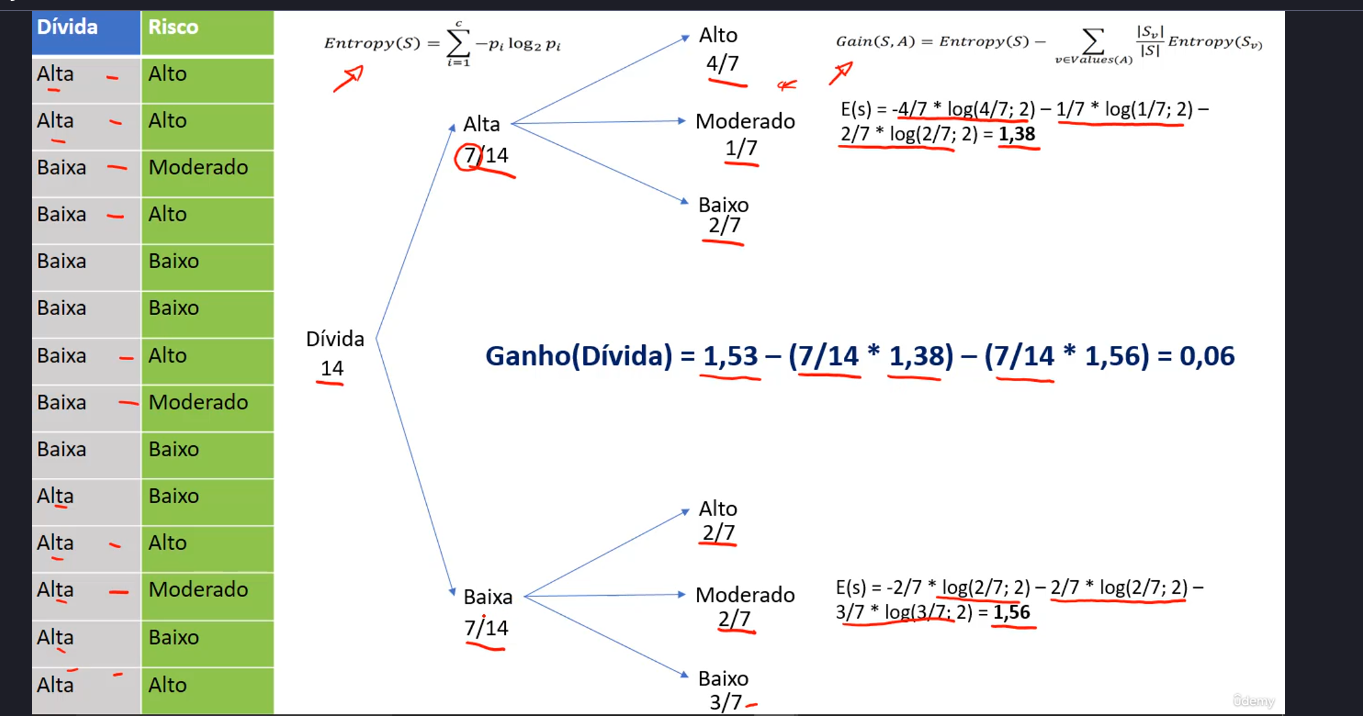

In [44]:
E_s_Divida_Alta = -((4 / 7) * np.log2(4/7) + (1 / 7) * np.log2(1/7) + (2/ 7) * np.log2(2/7) )
print(E_s_Divida_Alta)

E_s_Divida_Baixa = -((2 / 7) * np.log2(2/7) + (2 / 7) * np.log2(2/7) + (3/ 7) * np.log2(3/7) )
print(E_s_Divida_Baixa)

1.3787834934861753
1.5566567074628228


## Ganho divida = Entropia do risco geral (H_s) - (atributo* E(Dívida _ alta) + atributo* E(dívida_ baixa))

In [45]:
Ganho_divida =  (H_s) - (7/14* E_s_Divida_Alta + 7/14* E_s_Divida_Baixa )
Ganho_divida

0.0628988943740183

Até o momento, o histórico do crédito é mais significativo;

### Cálculo do ganho pela Garantia

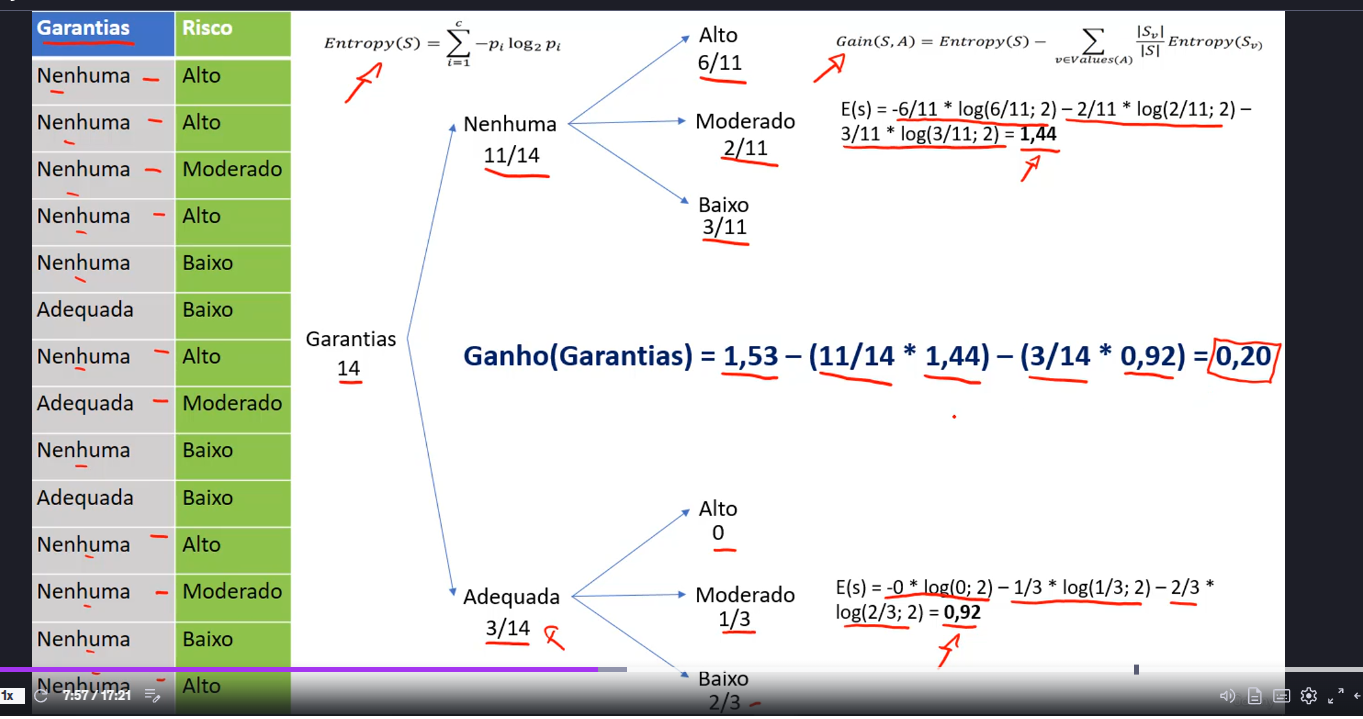

In [46]:
E_s_Garantia_Nenhuma = -((6 / 11) * np.log2(6/11) + (2/11) * np.log2(2/11) + (3/11) * np.log2(3/11) )
print(E_s_Garantia_Nenhuma)

E_s_Garantia_Adequada = -(0 + (1 / 3) * np.log2(1/3) + (2/ 3) * np.log2(2/3) )
print(E_s_Garantia_Adequada)


1.4353713907745331
0.9182958340544896


## Ganho garantias  = Entropia do risco geral (H_s) - (atributo* (E_s_Garantia_Nenhuma) + atributo* (E_s_Garantia_Adequada))

In [47]:
Ganho_garantias =  (H_s) - (11/14* E_s_Garantia_Nenhuma + 3/14* E_s_Garantia_Adequada )
Ganho_garantias

0.2060495090854222

Até o momento, o histórico do crédito ainda é o mais significativo;

In [48]:
print(' Ganho histórico:{:.2f}, Ganho Dívida : {:.2f} e Ganho Garantias : {:.2f}'.format(Ganho_historico_credito,Ganho_divida,Ganho_garantias))

 Ganho histórico:0.27, Ganho Dívida : 0.06 e Ganho Garantias : 0.21


## cálculo da renda

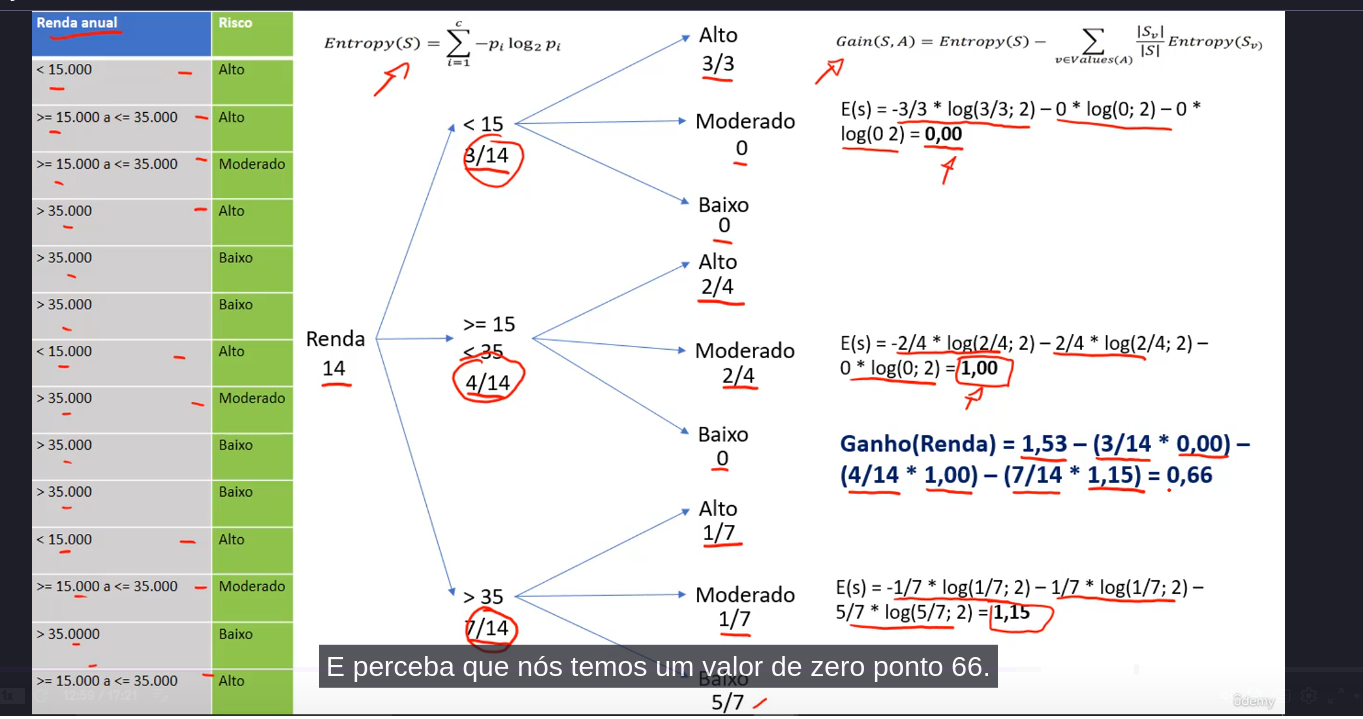

In [49]:
E_s_Renda_menor15 = -((3 / 3) * np.log2(3/3) + 0 + 0 )
print(E_s_Renda_menor15)

E_s_Renda_maior15_menor35 = -( (2 / 4) * np.log2(2/4) + (2/ 4) * np.log2(2/4) + 0 )
print(E_s_Renda_maior15_menor35)

E_s_Renda_maior35 = -( (1/7) * np.log2(1/7) + (1/7 * np.log2(1/7)) + (5/ 7) * np.log2(5/7) )
print(E_s_Renda_maior35)


-0.0
1.0
1.1488348542809166


## Ganho renda  = Entropia do risco geral (H_s) - (atributo* (E_s_Renda_menor15) + atributo* (E_s_Renda_maior15_menor35) + atributo* (E_s_Renda_maior35))

In [50]:
Ganho_renda=  (H_s) - (3/14* E_s_Renda_menor15 + 4/14* E_s_Renda_maior15_menor35 + (7/14)* E_s_Renda_maior35 )
Ganho_renda

0.6704872819937734

In [51]:
print(' Ganho da Renda: {:.2f} , Ganho histórico:{:.2f}, Ganho Dívida : {:.2f} e Ganho Garantias : {:.2f}'.format(Ganho_renda,Ganho_historico_credito,Ganho_divida,Ganho_garantias))

 Ganho da Renda: 0.67 , Ganho histórico:0.27, Ganho Dívida : 0.06 e Ganho Garantias : 0.21


Alta probabilidade, a renda estará na raiz da árvore de decisão. 

Para cada um desses ramos teremos que repetir os mesmos cálculos



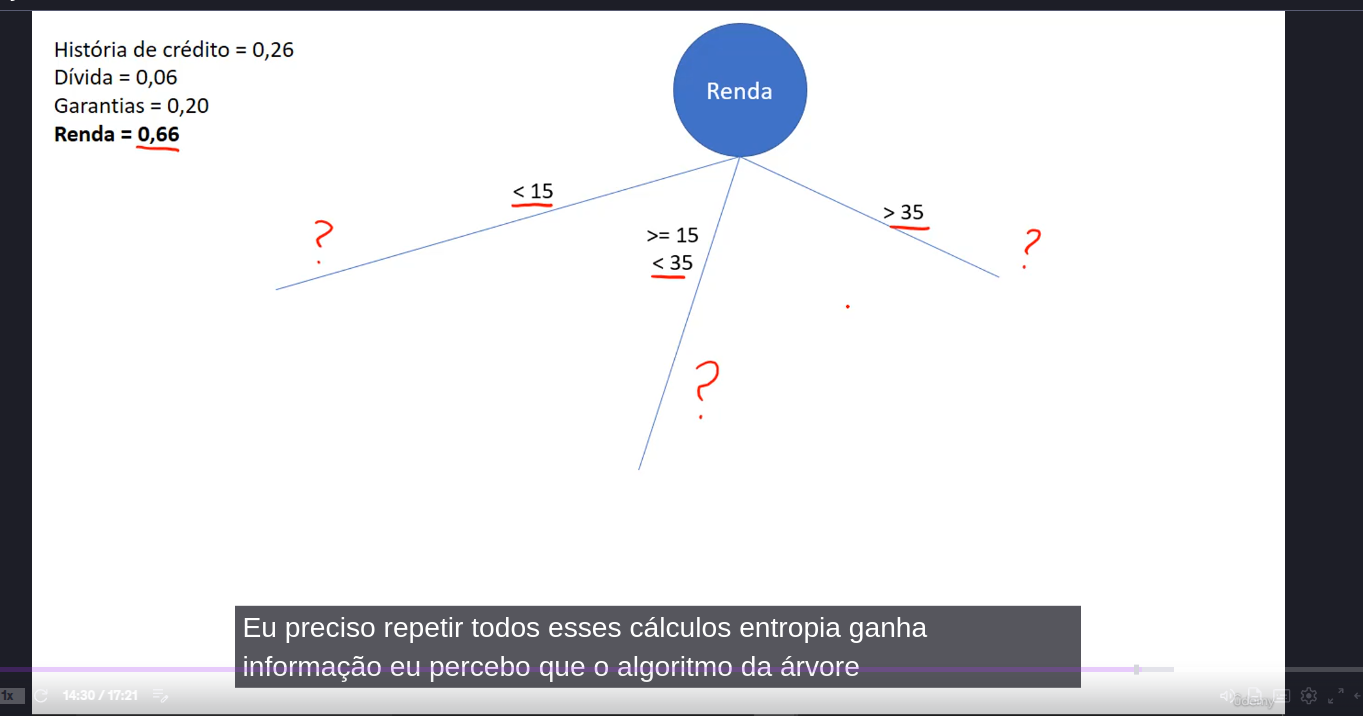

repeti o cálculo, mas fixando a renda da faixa em análise. 

dívida estava bem baixa o ganho, pode acontecer que esse atributo que teve um ganho de 0,06 pode não entrar na árvore de decisão porque ele tem um ganho pequeno. 

Nesse caso, os atributos que têm pouca informação podem ser excluídos da árvore.  



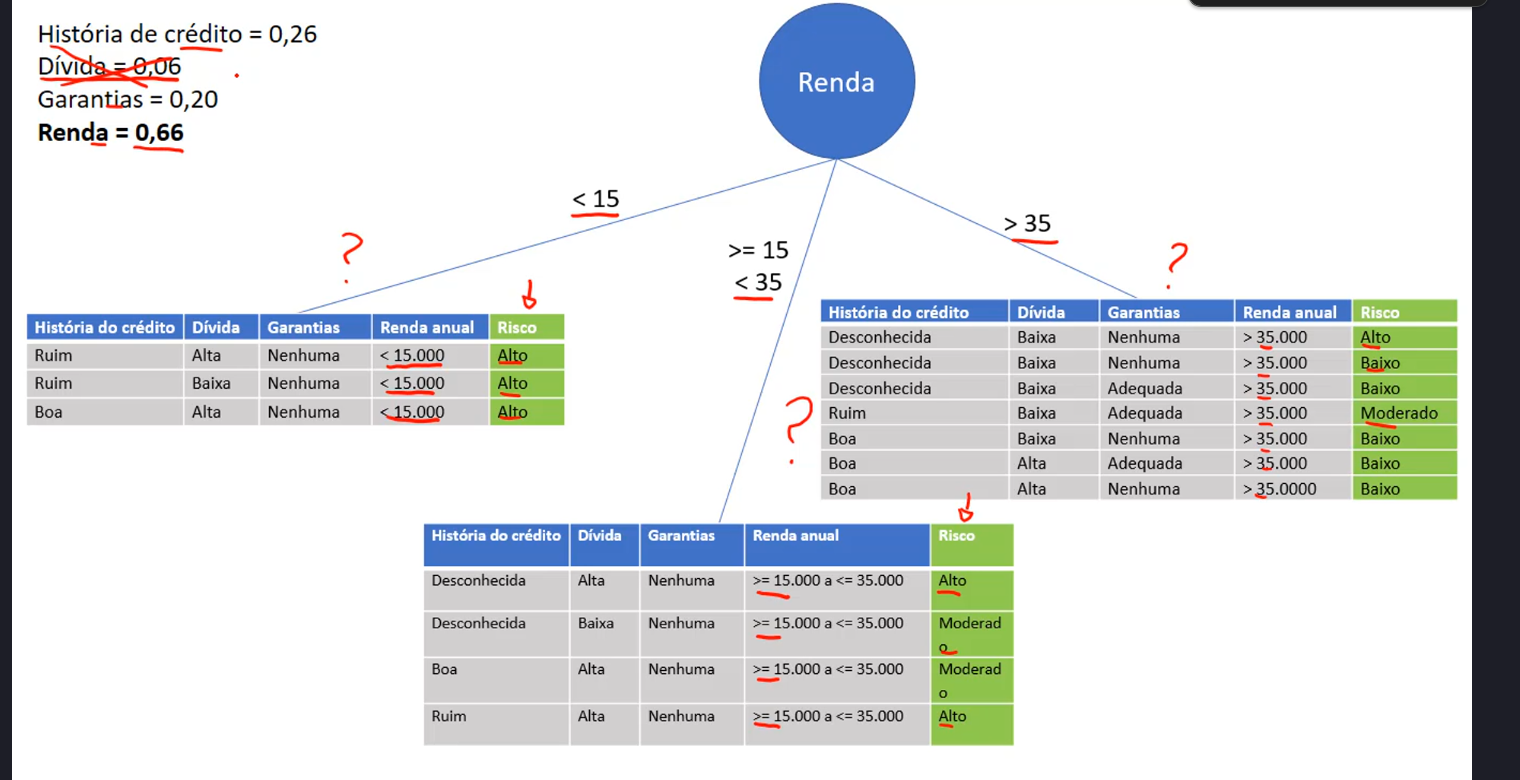

# 4.6) 

- split, vemos para a parametrização de árvore de decisão.  

Quando você pega algum algorítmo que você vai precisar verificar quais parâmetros seu algoritmo recebe. 

- Split indica divisão

Depois da árvore completa:
poda nas árvores de decisão, onde naqueles atributos que eles têm pouco ganho de informação. Tirar as partes desnecessárias. 

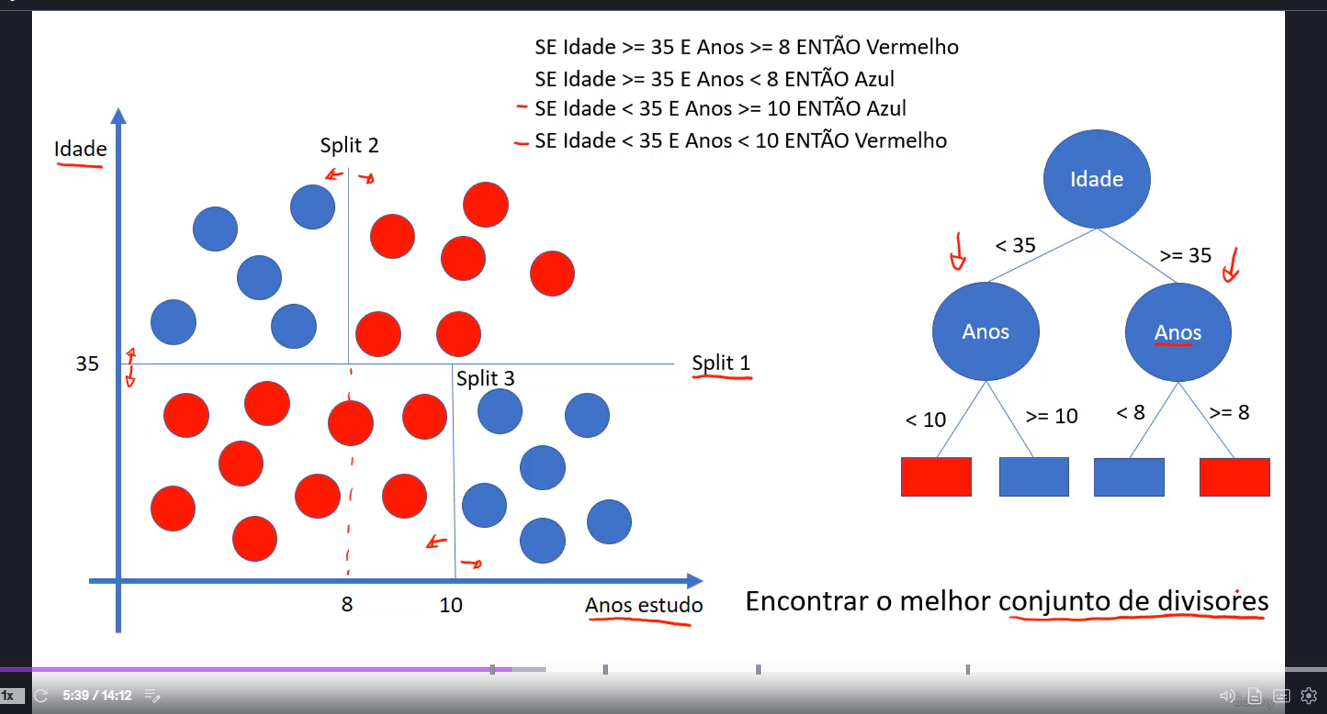

Depois da árvore completa:

poda nas árvores de decisão, onde naqueles atributos que eles têm pouco ganho de informação. Tirar as partes desnecessárias. 

- <b> Overfitting</b>, no Machine Learning, o algoritmo se adapta demais aos dados de treinamento. Consegue registrar bem os dados de treinamento, porém com base de teste, pode dar mais erros. 

Overfitting ocorre quando um modelo de machine learning se ajusta demais aos dados de treinamento, capturando ruído e padrões específicos que não se generalizam bem para novos dados. Isso faz com que o modelo tenha alta precisão no treinamento, mas baixo desempenho em novos dados.

Overfitting: é quando o modelo está excessivamente ajustado aos dados de treinamento, aprendendo detalhes e variações que não são relevantes para dados novos. Isso acontece porque o modelo fica muito complexo, capturando até o ruído dos dados em vez de apenas os padrões gerais. Como resultado, ele se sai bem nos dados de treino, mas tem baixo desempenho quando recebe novos dados.

Um exemplo clássico seria um aluno que memoriza todas as respostas de um simulado em vez de entender os conceitos—ele pode tirar 10 no treino, mas na prova real, se as perguntas mudarem um pouco, ele se sai mal. 📉


Poda em árvores de decisão

- * Bias (viés) 

- erro por classificação errada


- * Variância 

- Erros por sensibilidade pequena a mudanças na base de treinamento

- Pode levar a overfitting. 

Na poda também pode perder um pouco de informação. Mas, pode ter um desempenho melhor, mesmo assim. 



árvores de decisão

- * Vantagens 

- Fácil interpretação

- Não precisa normalização ou padronização. 

- Rápido para classificar novos registros

- * Desvantagens

- Geração de árvores muito complexas (overfitting)

- Pequenas mudanças nos dados pode mudar a árvore (poda pode ajudar) (criando um novo atributo) 

- Problema NP-Completo (NP- estrutura dos dados) para construir a árvore.

- * popular em meados dos anos 90

- * Upgrades com o random forest (florestas randômicas) melhoram o desempenho (usado no Kinect da Microsoft → captura de movimento - mexe o braço e no desenho mexe)
 
random forest similar ao lstm ou redes neurais,

- * CART - classification and regression trees
